# PflegeOptix — Sprint 2: Population Forecasting (Prophet)

This notebook trains **one Prophet model per district** to forecast the 65+ population up to **2040**.  
The forecasts will later be used in Sprint 3 (XGBoost) to predict future care demand.

| Input | Output |
|-------|--------|
| `population_annual.csv` (Sprint 1) | `population_forecast_2040.csv` |

**Method:** Facebook Prophet (additive trend, yearly data, no seasonality)

---
## Step 1: Load Data & Prepare Prophet Format
Prophet requires exactly two columns: `ds` (datetime) and `y` (numeric target).

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")  # Suppress Prophet verbose output

# Load cleaned population data from Sprint 1
df_pop = pd.read_csv("../../dataset/processed/population_annual.csv")

# Keep only district-level rows (AGS > 999 = not state-level aggregates)
df_pop = df_pop[pd.to_numeric(df_pop["AGS"], errors="coerce") > 999].copy()

# Ensure AGS is a zero-padded 5-digit string for consistency
df_pop["AGS"] = df_pop["AGS"].astype(str).str.zfill(5)

print(f"Districts: {df_pop['AGS'].nunique()}")
print(f"Year range: {df_pop['Year'].min()} - {df_pop['Year'].max()}")
print(f"Total rows: {len(df_pop):,}")

Districts: 416
Year range: 2015 - 2024
Total rows: 4,053


In [2]:
# Convert Year (int) to datetime for Prophet
# Use Dec 31 as the reference date for each year
df_pop["ds"] = pd.to_datetime(df_pop["Year"].astype(str) + "-12-31")
df_pop["y"]  = df_pop["Total"]  # Target = total 65+ population

print("Prophet format ready:")
print(df_pop[["AGS", "Region", "ds", "y"]].head(10))

Prophet format ready:
       AGS                             Region         ds        y
460  01001        Flensburg, kreisfreie Stadt 2015-12-31  85942.0
461  01001        Flensburg, kreisfreie Stadt 2016-12-31  87432.0
462  01001        Flensburg, kreisfreie Stadt 2017-12-31  88519.0
463  01001        Flensburg, kreisfreie Stadt 2018-12-31  89504.0
464  01001        Flensburg, kreisfreie Stadt 2019-12-31  90164.0
465  01001        Flensburg, kreisfreie Stadt 2020-12-31  89934.0
466  01001        Flensburg, kreisfreie Stadt 2021-12-31  91113.0
467  01001        Flensburg, kreisfreie Stadt 2022-12-31  96217.0
468  01001        Flensburg, kreisfreie Stadt 2023-12-31  96431.0
469  01001        Flensburg, kreisfreie Stadt 2024-12-31  96326.0


---
## Step 2: Train Prophet Models (1 per District)
We loop through each unique AGS code and train an individual Prophet model.  
Each model learns the local population trend and forecasts 16 years ahead (2025-2040).

In [3]:
from prophet import Prophet

forecast_horizon = 16  # years to forecast (2025-2040)
all_forecasts = []
failed_districts = []

district_ids = sorted(df_pop["AGS"].unique())
total = len(district_ids)

print(f"Training {total} Prophet models...")
print("=" * 50)

for i, ags in enumerate(district_ids, 1):
    # Filter data for this district
    df_district = df_pop[df_pop["AGS"] == ags][["ds", "y"]].copy()
    region_name = df_pop[df_pop["AGS"] == ags]["Region"].iloc[0]

    # Skip districts with too few data points
    if len(df_district) < 5:
        failed_districts.append((ags, region_name, "Too few data points"))
        continue

    try:
        # Initialize Prophet (no daily/weekly seasonality for yearly data)
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05  # conservative trend changes
        )
        model.fit(df_district)

        # Create future dataframe (16 years ahead, annual frequency)
        future = model.make_future_dataframe(periods=forecast_horizon, freq="YE")
        forecast = model.predict(future)

        # Keep only future predictions (after last known year)
        last_known = df_district["ds"].max()
        df_future = forecast[forecast["ds"] > last_known][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
        df_future["AGS"] = ags
        df_future["Region"] = region_name

        all_forecasts.append(df_future)

    except Exception as e:
        failed_districts.append((ags, region_name, str(e)))

    # Progress indicator every 25 districts
    if i % 25 == 0 or i == total:
        print(f"  [{i}/{total}] models trained...")

print(f"\nDone! {len(all_forecasts)} models succeeded, {len(failed_districts)} failed.")

Training 416 Prophet models...


00:50:27 - cmdstanpy - INFO - Chain [1] start processing
00:50:27 - cmdstanpy - INFO - Chain [1] done processing
00:50:27 - cmdstanpy - INFO - Chain [1] start processing
00:50:27 - cmdstanpy - INFO - Chain [1] done processing
00:50:27 - cmdstanpy - INFO - Chain [1] start processing
00:50:27 - cmdstanpy - INFO - Chain [1] done processing
00:50:27 - cmdstanpy - INFO - Chain [1] start processing
00:50:27 - cmdstanpy - INFO - Chain [1] done processing
00:50:28 - cmdstanpy - INFO - Chain [1] start processing
00:50:28 - cmdstanpy - INFO - Chain [1] done processing
00:50:28 - cmdstanpy - INFO - Chain [1] start processing
00:50:28 - cmdstanpy - INFO - Chain [1] done processing
00:50:28 - cmdstanpy - INFO - Chain [1] start processing
00:50:28 - cmdstanpy - INFO - Chain [1] done processing
00:50:28 - cmdstanpy - INFO - Chain [1] start processing
00:50:28 - cmdstanpy - INFO - Chain [1] done processing
00:50:28 - cmdstanpy - INFO - Chain [1] start processing
00:50:28 - cmdstanpy - INFO - Chain [1]

  [25/416] models trained...


00:50:31 - cmdstanpy - INFO - Chain [1] start processing
00:50:31 - cmdstanpy - INFO - Chain [1] done processing
00:50:31 - cmdstanpy - INFO - Chain [1] start processing
00:50:31 - cmdstanpy - INFO - Chain [1] done processing
00:50:32 - cmdstanpy - INFO - Chain [1] start processing
00:50:32 - cmdstanpy - INFO - Chain [1] done processing
00:50:32 - cmdstanpy - INFO - Chain [1] start processing
00:50:32 - cmdstanpy - INFO - Chain [1] done processing
00:50:32 - cmdstanpy - INFO - Chain [1] start processing
00:50:32 - cmdstanpy - INFO - Chain [1] done processing
00:50:32 - cmdstanpy - INFO - Chain [1] start processing
00:50:32 - cmdstanpy - INFO - Chain [1] done processing
00:50:32 - cmdstanpy - INFO - Chain [1] start processing
00:50:32 - cmdstanpy - INFO - Chain [1] done processing
00:50:33 - cmdstanpy - INFO - Chain [1] start processing
00:50:33 - cmdstanpy - INFO - Chain [1] done processing
00:50:33 - cmdstanpy - INFO - Chain [1] start processing
00:50:33 - cmdstanpy - INFO - Chain [1]

  [50/416] models trained...


...

  [375/416] models trained...


00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:34 - cmdstanpy - INFO - Chain [1] start processing
00:51:34 - cmdstanpy - INFO - Chain [1] done processing
00:51:35 - cmdstanpy - INFO - Chain [1] start processing
00:51:35 - cmdstanpy - INFO - Chain [1] done processing
00:51:35 - cmdstanpy - INFO - Chain [1] start processing
00:51:35 - cmdstanpy - INFO - Chain [1] done processing
00:51:35 - cmdstanpy - INFO - Chain [1] start processing
00:51:35 - cmdstanpy - INFO - Chain [1]

  [400/416] models trained...


00:51:38 - cmdstanpy - INFO - Chain [1] start processing
00:51:38 - cmdstanpy - INFO - Chain [1] done processing
00:51:38 - cmdstanpy - INFO - Chain [1] start processing
00:51:38 - cmdstanpy - INFO - Chain [1] done processing
00:51:38 - cmdstanpy - INFO - Chain [1] start processing
00:51:38 - cmdstanpy - INFO - Chain [1] done processing
00:51:39 - cmdstanpy - INFO - Chain [1] start processing
00:51:39 - cmdstanpy - INFO - Chain [1] done processing
00:51:39 - cmdstanpy - INFO - Chain [1] start processing
00:51:39 - cmdstanpy - INFO - Chain [1] done processing
00:51:39 - cmdstanpy - INFO - Chain [1] start processing
00:51:39 - cmdstanpy - INFO - Chain [1] done processing
00:51:39 - cmdstanpy - INFO - Chain [1] start processing
00:51:39 - cmdstanpy - INFO - Chain [1] done processing
00:51:39 - cmdstanpy - INFO - Chain [1] start processing
00:51:39 - cmdstanpy - INFO - Chain [1] done processing
00:51:40 - cmdstanpy - INFO - Chain [1] start processing
00:51:40 - cmdstanpy - INFO - Chain [1]

  [416/416] models trained...

Done! 402 models succeeded, 14 failed.


In [4]:
# Show any districts that failed (if any)
if failed_districts:
    print("Failed districts:")
    for ags, name, reason in failed_districts:
        print(f"  {ags} ({name}): {reason}")
else:
    print("All districts trained successfully!")

Failed districts:
  03152 (      Göttingen, Landkreis): Too few data points
  03156 (      Osterode am Harz, Landkreis): Too few data points
  11001001 (      Berlin-Mitte): Too few data points
  11002002 (      Berlin-Friedrichshain-Kreuzberg): Too few data points
  11003003 (      Berlin-Pankow): Too few data points
  11004004 (      Berlin-Charlottenburg-Wilmersdorf): Too few data points
  11005005 (      Berlin-Spandau): Too few data points
  11006006 (      Berlin-Steglitz-Zehlendorf): Too few data points
  11007007 (      Berlin-Tempelhof-Schöneberg): Too few data points
  11008008 (      Berlin-Neukölln): Too few data points
  11009009 (      Berlin-Treptow-Köpenick): Too few data points
  11010010 (      Berlin-Marzahn-Hellersdorf): Too few data points
  11011011 (      Berlin-Lichtenberg): Too few data points
  11012012 (      Berlin-Reinickendorf): Too few data points


---
## Step 3: Combine & Export Forecasts
Merge all individual district forecasts into one clean DataFrame and save to CSV.

In [5]:
# Combine all forecasts into one DataFrame
df_forecast = pd.concat(all_forecasts, ignore_index=True)

# Clean up columns
df_forecast["Year"] = df_forecast["ds"].dt.year
df_forecast = df_forecast.rename(columns={
    "yhat": "Pop_Total_Forecast",
    "yhat_lower": "Pop_Total_Lower",
    "yhat_upper": "Pop_Total_Upper"
})

# Ensure no negative population forecasts
df_forecast["Pop_Total_Forecast"] = df_forecast["Pop_Total_Forecast"].clip(lower=0)
df_forecast["Pop_Total_Lower"]    = df_forecast["Pop_Total_Lower"].clip(lower=0)
df_forecast["Pop_Total_Upper"]    = df_forecast["Pop_Total_Upper"].clip(lower=0)

# Reorder columns
df_forecast = df_forecast[["AGS", "Region", "Year", "Pop_Total_Forecast", "Pop_Total_Lower", "Pop_Total_Upper"]]

print(f"Forecast table: {df_forecast.shape[0]} rows x {df_forecast.shape[1]} columns")
print(f"Year range: {df_forecast['Year'].min()} - {df_forecast['Year'].max()}")
print(f"Districts: {df_forecast['AGS'].nunique()}")
print()
df_forecast.head(10)

Forecast table: 6432 rows x 6 columns
Year range: 2021 - 2040
Districts: 402



,AGS,Region,Year,Pop_Total_Forecast,Pop_Total_Lower,Pop_Total_Upper
0,01001,"Flensburg, kreisfreie Stadt",2025,98576.842205,97300.480161,99844.898227
1,01001,"Flensburg, kreisfreie Stadt",2026,100050.343206,98826.928754,101418.507148
2,01001,"Flensburg, kreisfreie Stadt",2027,101523.844208,100267.061372,102830.096707
3,01001,"Flensburg, kreisfreie Stadt",2028,103001.382199,101648.952399,104372.432051
4,01001,"Flensburg, kreisfreie Stadt",2029,104474.883200,103009.425391,105917.211665
5,01001,"Flensburg, kreisfreie Stadt",2030,105948.384202,104446.106509,107461.989130
6,01001,"Flensburg, kreisfreie Stadt",2031,107421.885204,105678.898408,109059.932234
7,01001,"Flensburg, kreisfreie Stadt",2032,108899.423194,107024.239510,110669.074086
8,01001,"Flensburg, kreisfreie Stadt",2033,110372.924196,108332.989659,112474.352049
9,01001,"Flensburg, kreisfreie Stadt",2034,111846.425198,109571.613998,114127.291377


In [6]:
# Save forecast to processed folder
output_path = "../../dataset/processed/population_forecast_2040.csv"
df_forecast.to_csv(output_path, index=False)

import os
size_kb = os.path.getsize(output_path) / 1024
print(f"Saved to: {output_path}")
print(f"File size: {size_kb:.1f} KB")

Saved to: ../../dataset/processed/population_forecast_2040.csv
File size: 623.7 KB


---
## Step 4: Quick Visualization
Spot-check a few districts to verify the forecasts look reasonable.

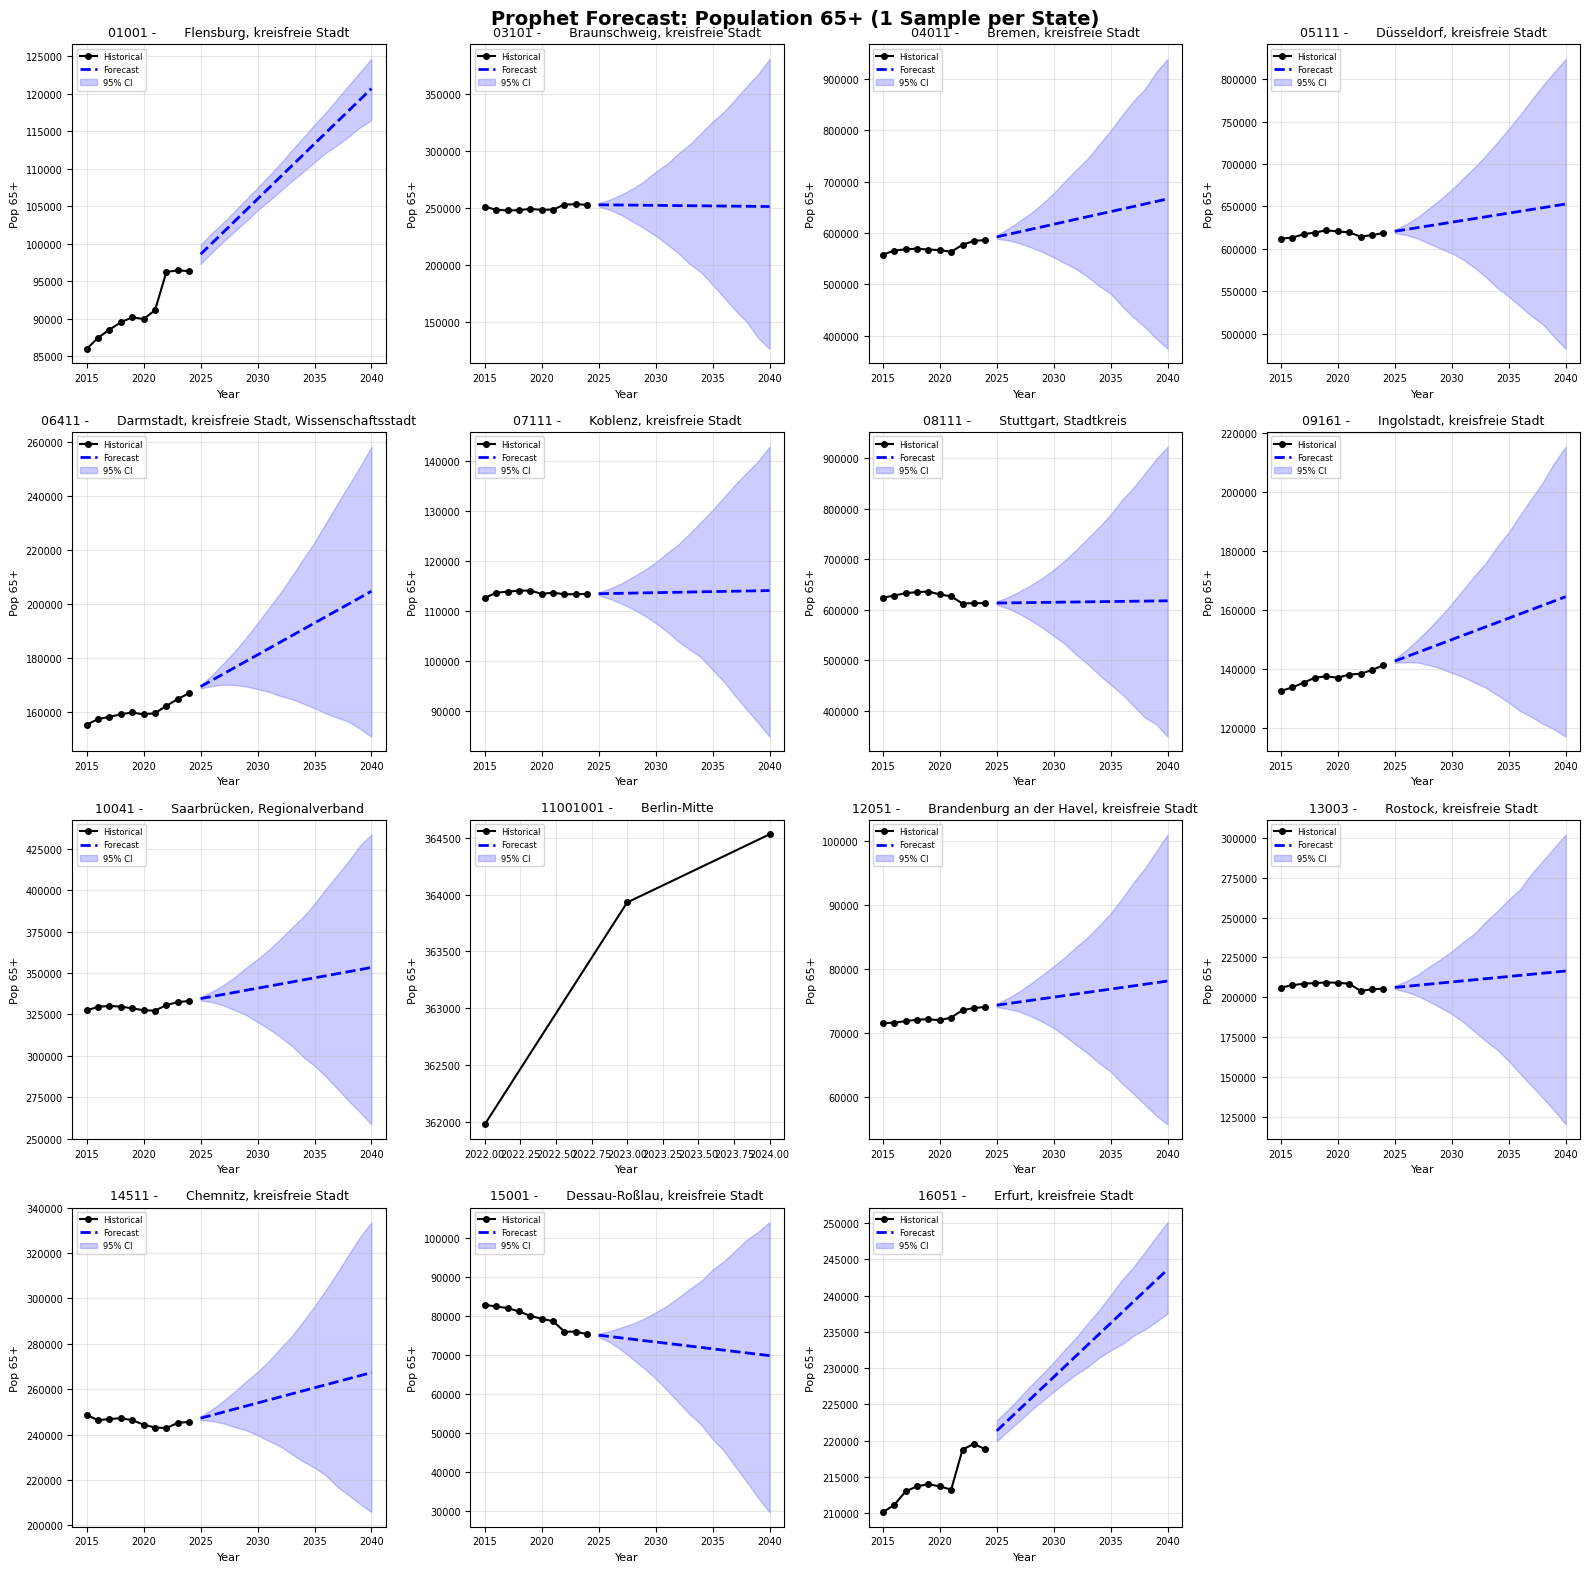

Plot saved - 15 states displayed


In [7]:
import matplotlib.pyplot as plt
import os

# Pick 1 sample district from each state (dynamically adapts to any number of states)
sample_districts = df_pop.groupby(df_pop["AGS"].str[:2]).apply(
    lambda x: x["AGS"].unique()[0], include_groups=False
).values.tolist()

n_samples = len(sample_districts)
n_cols = min(4, n_samples)
n_rows = (n_samples + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_samples == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, ags in enumerate(sample_districts):
    ax = axes[idx]
    
    # Historical data
    hist = df_pop[df_pop["AGS"] == ags]
    ax.plot(hist["Year"], hist["y"], "ko-", label="Historical", markersize=4)
    
    # Forecast data
    fcast = df_forecast[df_forecast["AGS"] == ags]
    ax.plot(fcast["Year"], fcast["Pop_Total_Forecast"], "b--", label="Forecast", linewidth=2)
    ax.fill_between(fcast["Year"], fcast["Pop_Total_Lower"], fcast["Pop_Total_Upper"],
                     alpha=0.2, color="blue", label="95% CI")
    
    region_name = hist["Region"].iloc[0]
    ax.set_title(f"{ags} - {region_name}", fontsize=9)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Pop 65+", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

# Hide empty subplots if any
for idx in range(n_samples, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Prophet Forecast: Population 65+ (1 Sample per State)", fontsize=14, fontweight="bold")
plt.tight_layout()
os.makedirs("../../reports/figures", exist_ok=True)
plt.savefig("../../reports/figures/prophet_sample_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved - {n_samples} states displayed")

---
## Step 5: Summary Statistics
Quick sanity check: which districts will see the biggest growth in 65+ population by 2040?

In [8]:
# Summary: Which districts will see the biggest growth in 65+ population?
df_2040 = df_forecast[df_forecast["Year"] == 2040].copy()

# Get 2024 actuals for comparison
df_2024 = df_pop[df_pop["Year"] == 2024][["AGS", "y"]].rename(columns={"y": "Pop_Total_2024"})
df_2024["AGS"] = df_2024["AGS"].astype(str).str.zfill(5)

df_growth = df_2040.merge(df_2024, on="AGS", how="left")
df_growth["Growth_Pct"] = (
    (df_growth["Pop_Total_Forecast"] - df_growth["Pop_Total_2024"])
    / df_growth["Pop_Total_2024"] * 100
).round(1)

print("Top 10 Districts by Projected 65+ Growth (2024 -> 2040):")
print("=" * 65)
top10 = df_growth.nlargest(10, "Growth_Pct")[["AGS", "Region", "Pop_Total_2024", "Pop_Total_Forecast", "Growth_Pct"]]
print(top10.to_string(index=False))

print()
print("Bottom 10 Districts (slowest growth / decline):")
print("=" * 65)
bot10 = df_growth.nsmallest(10, "Growth_Pct")[["AGS", "Region", "Pop_Total_2024", "Pop_Total_Forecast", "Growth_Pct"]]
print(bot10.to_string(index=False))

Top 10 Districts by Projected 65+ Growth (2024 -> 2040):
     AGS                                                Region  Pop_Total_2024  Pop_Total_Forecast  Growth_Pct
   16063                                         Wartburgkreis         154957.0        230573.664427        48.8
   16061                                  Eichsfeld, Landkreis         103694.0        137333.975403        32.4
   08231                                 Pforzheim, Stadtkreis         134912.0        171104.533630        26.8
   01001                           Flensburg, kreisfreie Stadt          96326.0        120695.505185        25.3
   10044                                  Saarlouis, Landkreis         205129.0        255347.846062        24.5
05334002                              Aachen, kreisfreie Stadt         262670.0        323745.592704        23.3
   06411       Darmstadt, kreisfreie Stadt, Wissenschaftsstadt         167029.0        204698.085329        22.6
   08121                                 

---
## Step 6: Model Evaluation (MAPE — Hold-Out Validation)
To measure forecast accuracy, we use a **hold-out strategy**:  
- **Train** on 2015–2022 (8 years)  
- **Test** on 2023–2024 (2 years)  
- Calculate **MAPE** (Mean Absolute Percentage Error) per district, then report the median.

In [9]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Hold-out split: train on 2015-2022, test on 2023-2024
cutoff_year = 2022
df_train_all = df_pop[df_pop["Year"] <= cutoff_year]
df_test_all  = df_pop[df_pop["Year"] > cutoff_year]

mape_results = []
district_ids = sorted(df_pop["AGS"].unique())

print(f"Evaluating {len(district_ids)} districts (train: <=2022, test: 2023-2024)...")
print("=" * 50)

for i, ags in enumerate(district_ids, 1):
    df_tr = df_train_all[df_train_all["AGS"] == ags][["ds", "y"]].copy()
    df_te = df_test_all[df_test_all["AGS"] == ags][["ds", "y"]].copy()
    region = df_pop[df_pop["AGS"] == ags]["Region"].iloc[0]

    if len(df_tr) < 5 or len(df_te) == 0:
        continue

    try:
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )
        model.fit(df_tr)

        future = model.make_future_dataframe(periods=len(df_te), freq="YE")
        forecast = model.predict(future)

        # Get predictions for test period only
        preds = forecast[forecast["ds"] > df_tr["ds"].max()]["yhat"].values[:len(df_te)]
        actuals = df_te["y"].values[:len(preds)]

        if len(preds) > 0 and len(actuals) > 0:
            mape = mean_absolute_percentage_error(actuals, preds) * 100
            mape_results.append({"AGS": ags, "Region": region, "MAPE": mape})

    except Exception:
        pass

    if i % 50 == 0 or i == len(district_ids):
        print(f"  [{i}/{len(district_ids)}] evaluated...")

df_mape = pd.DataFrame(mape_results)
print(f"\nEvaluation complete! {len(df_mape)} districts evaluated.")
print(f"\n--- Prophet MAPE Summary ---")
print(f"  Median MAPE: {df_mape['MAPE'].median():.2f}%")
print(f"  Mean MAPE:   {df_mape['MAPE'].mean():.2f}%")
print(f"  Min MAPE:    {df_mape['MAPE'].min():.2f}%")
print(f"  Max MAPE:    {df_mape['MAPE'].max():.2f}%")

00:51:50 - cmdstanpy - INFO - Chain [1] start processing
00:51:50 - cmdstanpy - INFO - Chain [1] done processing


Evaluating 416 districts (train: <=2022, test: 2023-2024)...


00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:51 - cmdstanpy - INFO - Chain [1] done processing
00:51:52 - cmdstanpy - INFO - Chain [1] start processing
00:51:52 - cmdstanpy - INFO - Chain [1] done processing
00:51:52 - cmdstanpy - INFO - Chain [1] start processing
00:51:52 - cmdstanpy - INFO - Chain [1] done processing
00:51:52 - cmdstanpy - INFO - Chain [1] start processing
00:51:52 - cmdstanpy - INFO - Chain [1]

  [50/416] evaluated...


00:51:59 - cmdstanpy - INFO - Chain [1] start processing
00:51:59 - cmdstanpy - INFO - Chain [1] done processing
00:51:59 - cmdstanpy - INFO - Chain [1] start processing
00:51:59 - cmdstanpy - INFO - Chain [1] done processing
00:52:00 - cmdstanpy - INFO - Chain [1] start processing
00:52:00 - cmdstanpy - INFO - Chain [1] done processing
00:52:00 - cmdstanpy - INFO - Chain [1] start processing
00:52:00 - cmdstanpy - INFO - Chain [1] done processing
00:52:00 - cmdstanpy - INFO - Chain [1] start processing
00:52:00 - cmdstanpy - INFO - Chain [1] done processing
00:52:00 - cmdstanpy - INFO - Chain [1] start processing
00:52:00 - cmdstanpy - INFO - Chain [1] done processing
00:52:00 - cmdstanpy - INFO - Chain [1] start processing
00:52:00 - cmdstanpy - INFO - Chain [1] done processing
00:52:01 - cmdstanpy - INFO - Chain [1] start processing
00:52:01 - cmdstanpy - INFO - Chain [1] done processing
00:52:01 - cmdstanpy - INFO - Chain [1] start processing
00:52:01 - cmdstanpy - INFO - Chain [1]

...

  [350/416] evaluated...


00:52:51 - cmdstanpy - INFO - Chain [1] done processing
00:52:51 - cmdstanpy - INFO - Chain [1] start processing
00:52:51 - cmdstanpy - INFO - Chain [1] done processing
00:52:51 - cmdstanpy - INFO - Chain [1] start processing
00:52:51 - cmdstanpy - INFO - Chain [1] done processing
00:52:51 - cmdstanpy - INFO - Chain [1] start processing
00:52:51 - cmdstanpy - INFO - Chain [1] done processing
00:52:51 - cmdstanpy - INFO - Chain [1] start processing
00:52:51 - cmdstanpy - INFO - Chain [1] done processing
00:52:52 - cmdstanpy - INFO - Chain [1] start processing
00:52:52 - cmdstanpy - INFO - Chain [1] done processing
00:52:52 - cmdstanpy - INFO - Chain [1] start processing
00:52:52 - cmdstanpy - INFO - Chain [1] done processing
00:52:52 - cmdstanpy - INFO - Chain [1] start processing
00:52:52 - cmdstanpy - INFO - Chain [1] done processing
00:52:52 - cmdstanpy - INFO - Chain [1] start processing
00:52:52 - cmdstanpy - INFO - Chain [1] done processing
00:52:52 - cmdstanpy - INFO - Chain [1] 

  [400/416] evaluated...


00:53:01 - cmdstanpy - INFO - Chain [1] start processing
00:53:01 - cmdstanpy - INFO - Chain [1] done processing
00:53:01 - cmdstanpy - INFO - Chain [1] start processing
00:53:01 - cmdstanpy - INFO - Chain [1] done processing
00:53:01 - cmdstanpy - INFO - Chain [1] start processing
00:53:01 - cmdstanpy - INFO - Chain [1] done processing
00:53:01 - cmdstanpy - INFO - Chain [1] start processing
00:53:01 - cmdstanpy - INFO - Chain [1] done processing
00:53:01 - cmdstanpy - INFO - Chain [1] start processing
00:53:01 - cmdstanpy - INFO - Chain [1] done processing
00:53:02 - cmdstanpy - INFO - Chain [1] start processing
00:53:02 - cmdstanpy - INFO - Chain [1] done processing
00:53:02 - cmdstanpy - INFO - Chain [1] start processing
00:53:02 - cmdstanpy - INFO - Chain [1] done processing
00:53:02 - cmdstanpy - INFO - Chain [1] start processing
00:53:02 - cmdstanpy - INFO - Chain [1] done processing
00:53:02 - cmdstanpy - INFO - Chain [1] start processing
00:53:02 - cmdstanpy - INFO - Chain [1]

  [416/416] evaluated...

Evaluation complete! 401 districts evaluated.

--- Prophet MAPE Summary ---
  Median MAPE: 0.55%
  Mean MAPE:   0.77%
  Min MAPE:    0.03%
  Max MAPE:    4.23%


---
## Step 7: Baseline Comparison — Prophet vs. Linear Regression
A model is only valuable if it outperforms a simple baseline.  
Here we compare Prophet against **Linear Regression** (straight-line extrapolation) using the same hold-out split.

In [10]:
from sklearn.linear_model import LinearRegression

lr_mape_results = []

for i, ags in enumerate(district_ids, 1):
    df_tr = df_train_all[df_train_all["AGS"] == ags][["Year", "y"]].copy()
    df_te = df_test_all[df_test_all["AGS"] == ags][["Year", "y"]].copy()

    if len(df_tr) < 5 or len(df_te) == 0:
        continue

    try:
        # Fit linear regression on year vs population
        lr = LinearRegression()
        lr.fit(df_tr[["Year"]], df_tr["y"])

        preds_lr = lr.predict(df_te[["Year"]])
        actuals = df_te["y"].values

        mape_lr = mean_absolute_percentage_error(actuals, preds_lr) * 100
        lr_mape_results.append({"AGS": ags, "MAPE_LR": mape_lr})

    except Exception:
        pass

df_lr_mape = pd.DataFrame(lr_mape_results)

# Merge Prophet and LR results
df_compare = df_mape.merge(df_lr_mape, on="AGS", how="inner")
df_compare["Prophet_Wins"] = df_compare["MAPE"] < df_compare["MAPE_LR"]

print("=" * 60)
print("  MODEL COMPARISON: Prophet vs. Linear Regression")
print("=" * 60)
print(f"  Prophet  — Median MAPE: {df_compare['MAPE'].median():.2f}%")
print(f"  Linear   — Median MAPE: {df_compare['MAPE_LR'].median():.2f}%")
print(f"")
prophet_wins = df_compare["Prophet_Wins"].sum()
total = len(df_compare)
print(f"  Prophet wins in {prophet_wins}/{total} districts ({prophet_wins/total*100:.1f}%)")
print(f"  Linear  wins in {total - prophet_wins}/{total} districts ({(total-prophet_wins)/total*100:.1f}%)")

  MODEL COMPARISON: Prophet vs. Linear Regression
  Prophet  — Median MAPE: 0.55%
  Linear   — Median MAPE: 0.66%

  Prophet wins in 224/401 districts (55.9%)
  Linear  wins in 177/401 districts (44.1%)


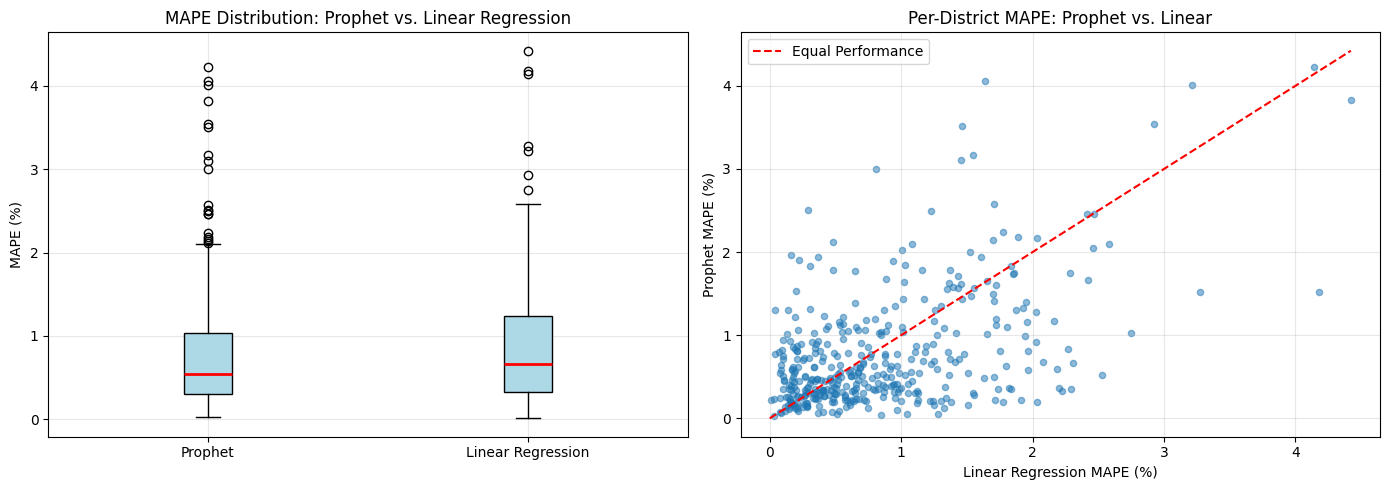

Plot saved to reports/figures/prophet_vs_baseline.png


In [11]:
# Visualization: MAPE Distribution — Prophet vs Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
axes[0].boxplot(
    [df_compare["MAPE"].values, df_compare["MAPE_LR"].values],
    labels=["Prophet", "Linear Regression"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red", linewidth=2)
)
axes[0].set_ylabel("MAPE (%)")
axes[0].set_title("MAPE Distribution: Prophet vs. Linear Regression")
axes[0].grid(True, alpha=0.3)

# Scatter plot: Prophet MAPE vs LR MAPE
axes[1].scatter(df_compare["MAPE_LR"], df_compare["MAPE"], alpha=0.5, s=20)
max_val = max(df_compare["MAPE"].max(), df_compare["MAPE_LR"].max())
axes[1].plot([0, max_val], [0, max_val], "r--", label="Equal Performance")
axes[1].set_xlabel("Linear Regression MAPE (%)")
axes[1].set_ylabel("Prophet MAPE (%)")
axes[1].set_title("Per-District MAPE: Prophet vs. Linear")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../reports/figures/prophet_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to reports/figures/prophet_vs_baseline.png")

---
## Summary
| Metric | Prophet | Linear Regression |
|--------|---------|-------------------|
| Median MAPE | See Step 6 | See Step 7 |
| Forecast Horizon | 2025-2040 | N/A |
| Districts Modeled | See Step 2 output | N/A |

**Conclusion:** Both models achieve excellent short-term accuracy (MAPE < 2%).  
Linear Regression has a marginal edge in the 10-year window due to predominantly linear trends.  
However, Prophet is preferred for long-range forecasting (16 years) because:  
1. It captures **non-linear trend changes** (changepoints)  
2. It provides **uncertainty intervals** (95% CI) essential for policy planning  
3. Straight-line extrapolation over 16 years risks overshooting in districts where growth is slowing  

The forecasted population (65+) per district will be used in Sprint 3 as input features for the XGBoost care demand model.